# Data engineering

Criação de instrumentos financeiros

In [1]:
import pandas as pd
import numpy as np

In [2]:
bitcoin = pd.read_csv("C:/Users/progr/OneDrive/Documentos/Miguel/PROJETOS/Rainha_de_Saba/01_data/raw/Dados_Históricos-Bitcoin.csv")
bitcoin = pd.DataFrame(bitcoin)
bitcoin

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,17.04.2025,"84.623,0","84.032,2","84.999,0","83.822,8","52,98K","0,70%"
1,16.04.2025,"84.032,2","83.648,1","85.438,2","83.143,5","63,97K","0,46%"
2,15.04.2025,"83.647,0","84.586,8","86.438,8","83.602,7","62,45K","-1,11%"
3,14.04.2025,"84.586,4","83.752,8","85.794,9","83.705,2","78,03K","1,02%"
4,13.04.2025,"83.734,4","85.282,5","85.999,5","83.049,6","70,93K","-1,83%"
...,...,...,...,...,...,...,...
1093,20.04.2022,"41.368,0","41.499,0","42.203,0","40.915,0","382,84M","-0,33%"
1094,19.04.2022,"41.503,0","40.809,0","41.746,0","40.585,0","268,28M","1,72%"
1095,18.04.2022,"40.803,0","39.700,0","41.095,0","38.577,0","484,26M","2,77%"
1096,17.04.2022,"39.703,0","40.382,0","40.599,0","39.561,0","210,01M","-1,68%"


**ATENÇÃO!**: o código abaixo não é uma norma. Neste caso específico, ele serve apenas para corrigir o tipo de dado numérico disposto no nosso dataset, que está inutitilizável, já que foi decimalizado com vírgulas (```1.000,0```), tornando-o uma string e não um float.

Para que o dado numérico seja tratado pelos recursos do pandas ou do numpy, ele precisa estar no formato próprio para tal: ```1000.0```. 

Para isso, a rotina abaixo substitui os pontos por espaços vazios e as vírgulas por pontos, e depois transforma o tipo do dado em float, para as colunas ```Último```, ```Abertura```, ```Máxima``` e ```Mínima```.

In [3]:
colunas_com_valores = ["Último", "Abertura", "Máxima", "Mínima"]
for col in colunas_com_valores:
    if bitcoin[col].dtype == "object":
        bitcoin[col] = bitcoin[col].str.replace(".", "", regex=False).str.replace(",", ".", regex=False).astype(float)

# Conversão da coluna "Data" do formato Object para DateTime
bitcoin["Data"] = pd.to_datetime(bitcoin["Data"], dayfirst=True)
# Amostragem de dataset
bitcoin

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,2025-04-17,84623.0,84032.2,84999.0,83822.8,"52,98K","0,70%"
1,2025-04-16,84032.2,83648.1,85438.2,83143.5,"63,97K","0,46%"
2,2025-04-15,83647.0,84586.8,86438.8,83602.7,"62,45K","-1,11%"
3,2025-04-14,84586.4,83752.8,85794.9,83705.2,"78,03K","1,02%"
4,2025-04-13,83734.4,85282.5,85999.5,83049.6,"70,93K","-1,83%"
...,...,...,...,...,...,...,...
1093,2022-04-20,41368.0,41499.0,42203.0,40915.0,"382,84M","-0,33%"
1094,2022-04-19,41503.0,40809.0,41746.0,40585.0,"268,28M","1,72%"
1095,2022-04-18,40803.0,39700.0,41095.0,38577.0,"484,26M","2,77%"
1096,2022-04-17,39703.0,40382.0,40599.0,39561.0,"210,01M","-1,68%"


## Intrumentos financeiros


#### Médias móveis

In [4]:
bitcoin['Média movel curta'] = bitcoin['Último'].rolling(window=10, min_periods=1,center=False).mean()
bitcoin['Média movel longa'] = bitcoin['Último'].rolling(window=30, min_periods=1,center=False).mean()
bitcoin['Sinal'] = np.where(bitcoin['Média movel curta'] > bitcoin['Média movel longa'], 1.0, 0.0)
bitcoin

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%,Média movel curta,Média movel longa,Sinal
0,2025-04-17,84623.0,84032.2,84999.0,83822.8,"52,98K","0,70%",84623.000000,84623.000000,0.0
1,2025-04-16,84032.2,83648.1,85438.2,83143.5,"63,97K","0,46%",84327.600000,84327.600000,0.0
2,2025-04-15,83647.0,84586.8,86438.8,83602.7,"62,45K","-1,11%",84100.733333,84100.733333,0.0
3,2025-04-14,84586.4,83752.8,85794.9,83705.2,"78,03K","1,02%",84222.150000,84222.150000,0.0
4,2025-04-13,83734.4,85282.5,85999.5,83049.6,"70,93K","-1,83%",84124.600000,84124.600000,0.0
...,...,...,...,...,...,...,...,...,...,...
1093,2022-04-20,41368.0,41499.0,42203.0,40915.0,"382,84M","-0,33%",39655.300000,35325.376667,1.0
1094,2022-04-19,41503.0,40809.0,41746.0,40585.0,"268,28M","1,72%",39947.500000,35698.613333,1.0
1095,2022-04-18,40803.0,39700.0,41095.0,38577.0,"484,26M","2,77%",40053.000000,36102.590000,1.0
1096,2022-04-17,39703.0,40382.0,40599.0,39561.0,"210,01M","-1,68%",40099.000000,36411.440000,1.0


#### Médias móveis exponenciais

In [5]:
def EMA(bitcoin, n):
    EMA = pd.Series(bitcoin['Último'].ewm(span=n, min_periods=n).mean(), name='EMA_'+ str(n))
    return EMA
bitcoin['EMA10'] = EMA(bitcoin, 10)
bitcoin['EMA30'] = EMA(bitcoin, 30)
bitcoin['EMA200'] = EMA(bitcoin, 200)
bitcoin.head()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%,Média movel curta,Média movel longa,Sinal,EMA10,EMA30,EMA200
0,2025-04-17,84623.0,84032.2,84999.0,83822.8,"52,98K","0,70%",84623.000000,84623.000000,0.0,NaN,NaN,NaN
1,2025-04-16,84032.2,83648.1,85438.2,83143.5,"63,97K","0,46%",84327.600000,84327.600000,0.0,NaN,NaN,NaN
2,2025-04-15,83647.0,84586.8,86438.8,83602.7,"62,45K","-1,11%",84100.733333,84100.733333,0.0,NaN,NaN,NaN
3,2025-04-14,84586.4,83752.8,85794.9,83705.2,"78,03K","1,02%",84222.150000,84222.150000,0.0,NaN,NaN,NaN
4,2025-04-13,83734.4,85282.5,85999.5,83049.6,"70,93K","-1,83%",84124.600000,84124.600000,0.0,NaN,NaN,NaN


#### Rate of change

In [6]:
def ROC(bitcoin, n):
    M = bitcoin.diff(n - 1)
    N = bitcoin.shift(n - 1)
    ROC = pd.Series(((M / N) * 100), name = 'ROC_' + str(n))
    return ROC
bitcoin['ROC10'] = ROC(bitcoin['Último'], 10)
bitcoin['ROC30'] = ROC(bitcoin['Último'], 30)
bitcoin

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%,Média movel curta,Média movel longa,Sinal,EMA10,EMA30,EMA200,ROC10,ROC30
0,2025-04-17,84623.0,84032.2,84999.0,83822.8,"52,98K","0,70%",84623.000000,84623.000000,0.0,NaN,NaN,NaN,NaN,NaN
1,2025-04-16,84032.2,83648.1,85438.2,83143.5,"63,97K","0,46%",84327.600000,84327.600000,0.0,NaN,NaN,NaN,NaN,NaN
2,2025-04-15,83647.0,84586.8,86438.8,83602.7,"62,45K","-1,11%",84100.733333,84100.733333,0.0,NaN,NaN,NaN,NaN,NaN
3,2025-04-14,84586.4,83752.8,85794.9,83705.2,"78,03K","1,02%",84222.150000,84222.150000,0.0,NaN,NaN,NaN,NaN,NaN
4,2025-04-13,83734.4,85282.5,85999.5,83049.6,"70,93K","-1,83%",84124.600000,84124.600000,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1093,2022-04-20,41368.0,41499.0,42203.0,40915.0,"382,84M","-0,33%",39655.300000,35325.376667,1.0,39537.236874,36168.837748,26338.453407,7.223763,36.501473
1094,2022-04-19,41503.0,40809.0,41746.0,40585.0,"268,28M","1,72%",39947.500000,35698.613333,1.0,39894.648352,36512.977248,26489.347067,4.415316,44.691933
1095,2022-04-18,40803.0,39700.0,41095.0,38577.0,"484,26M","2,77%",40053.000000,36102.590000,1.0,40059.803197,36789.752909,26631.773950,3.975231,34.055031
1096,2022-04-17,39703.0,40382.0,40599.0,39561.0,"210,01M","-1,68%",40099.000000,36411.440000,1.0,39994.929888,36977.704335,26761.838139,4.171805,33.012831


#### Momentum

In [7]:
def MOM(bitcoin, n):
    MOM = pd.Series(bitcoin.diff(n), name='Momentum_' + str(n))
    return MOM
bitcoin['MOM10'] = MOM(bitcoin['Último'], 10)
bitcoin['MOM30'] = MOM(bitcoin['Último'], 30)
bitcoin

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%,Média movel curta,Média movel longa,Sinal,EMA10,EMA30,EMA200,ROC10,ROC30,MOM10,MOM30
0,2025-04-17,84623.0,84032.2,84999.0,83822.8,"52,98K","0,70%",84623.000000,84623.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-16,84032.2,83648.1,85438.2,83143.5,"63,97K","0,46%",84327.600000,84327.600000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-04-15,83647.0,84586.8,86438.8,83602.7,"62,45K","-1,11%",84100.733333,84100.733333,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-04-14,84586.4,83752.8,85794.9,83705.2,"78,03K","1,02%",84222.150000,84222.150000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-04-13,83734.4,85282.5,85999.5,83049.6,"70,93K","-1,83%",84124.600000,84124.600000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1093,2022-04-20,41368.0,41499.0,42203.0,40915.0,"382,84M","-0,33%",39655.300000,35325.376667,1.0,39537.236874,36168.837748,26338.453407,7.223763,36.501473,3718.0,12189.4
1094,2022-04-19,41503.0,40809.0,41746.0,40585.0,"268,28M","1,72%",39947.500000,35698.613333,1.0,39894.648352,36512.977248,26489.347067,4.415316,44.691933,2922.0,11197.1
1095,2022-04-18,40803.0,39700.0,41095.0,38577.0,"484,26M","2,77%",40053.000000,36102.590000,1.0,40059.803197,36789.752909,26631.773950,3.975231,34.055031,1055.0,12119.3
1096,2022-04-17,39703.0,40382.0,40599.0,39561.0,"210,01M","-1,68%",40099.000000,36411.440000,1.0,39994.929888,36977.704335,26761.838139,4.171805,33.012831,460.0,9265.5


#### Índice de Força Relativa

In [8]:
def RSI(series, period):
    delta = series.diff().dropna()
    u = delta * 0
    d = u.copy()
    u[delta > 0] = delta[delta > 0]
    d[delta < 0] = -delta[delta < 0]
    u[u.index[period-1]] = np.mean( u[:period] ) #first value is sum of avg gains
    u = u.drop(u.index[:(period-1)])
    d[d.index[period-1]] = np.mean( d[:period] ) #first value is sum of avg losses
    d = d.drop(d.index[:(period-1)])
    rs = u.ewm(com=period-1, adjust=False).mean() / d.ewm(com=period-1, adjust=False).mean()
    return 100 - 100 / (1 + rs)
bitcoin['RSI10'] = RSI(bitcoin['Último'], 10)
bitcoin['RSI30'] = RSI(bitcoin['Último'], 30)
bitcoin['RSI200'] = RSI(bitcoin['Último'], 200)
bitcoin

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%,Média movel curta,Média movel longa,Sinal,EMA10,EMA30,EMA200,ROC10,ROC30,MOM10,MOM30,RSI10,RSI30,RSI200
0,2025-04-17,84623.0,84032.2,84999.0,83822.8,"52,98K","0,70%",84623.000000,84623.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-16,84032.2,83648.1,85438.2,83143.5,"63,97K","0,46%",84327.600000,84327.600000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-04-15,83647.0,84586.8,86438.8,83602.7,"62,45K","-1,11%",84100.733333,84100.733333,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-04-14,84586.4,83752.8,85794.9,83705.2,"78,03K","1,02%",84222.150000,84222.150000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-04-13,83734.4,85282.5,85999.5,83049.6,"70,93K","-1,83%",84124.600000,84124.600000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1093,2022-04-20,41368.0,41499.0,42203.0,40915.0,"382,84M","-0,33%",39655.300000,35325.376667,1.0,39537.236874,36168.837748,26338.453407,7.223763,36.501473,3718.0,12189.4,69.781659,65.955071,56.031851
1094,2022-04-19,41503.0,40809.0,41746.0,40585.0,"268,28M","1,72%",39947.500000,35698.613333,1.0,39894.648352,36512.977248,26489.347067,4.415316,44.691933,2922.0,11197.1,70.247106,66.122661,56.080762
1095,2022-04-18,40803.0,39700.0,41095.0,38577.0,"484,26M","2,77%",40053.000000,36102.590000,1.0,40059.803197,36789.752909,26631.773950,3.975231,34.055031,1055.0,12119.3,64.521444,64.421619,55.757528
1096,2022-04-17,39703.0,40382.0,40599.0,39561.0,"210,01M","-1,68%",40099.000000,36411.440000,1.0,39994.929888,36977.704335,26761.838139,4.171805,33.012831,460.0,9265.5,56.483077,61.835659,55.254556


#### Estocástico

In [9]:
def STOK(close, low, high, n):
    STOK = ((close - low.rolling(n).min()) / (high.rolling(n).max() - \
    low.rolling(n).min())) * 100
    return STOK
def STOD(close, low, high, n):
    STOK = ((close - low.rolling(n).min()) / (high.rolling(n).max() - \
    low.rolling(n).min())) * 100
    STOD = STOK.rolling(3).mean()
    return STOD
bitcoin['%K10'] = STOK(bitcoin['Último'], bitcoin['Mínima'], bitcoin['Máxima'], 10)
bitcoin['%D10'] = STOD(bitcoin['Último'], bitcoin['Mínima'], bitcoin['Máxima'], 10)
bitcoin['%K30'] = STOK(bitcoin['Último'], bitcoin['Mínima'], bitcoin['Máxima'], 30)
bitcoin['%D30'] = STOD(bitcoin['Último'], bitcoin['Mínima'], bitcoin['Máxima'], 30)
bitcoin['%K200'] = STOK(bitcoin['Último'], bitcoin['Mínima'], bitcoin['Máxima'], 200)
bitcoin['%D200'] = STOD(bitcoin['Último'], bitcoin['Mínima'], bitcoin['Máxima'], 200)
bitcoin

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%,Média movel curta,Média movel longa,Sinal,...,MOM30,RSI10,RSI30,RSI200,%K10,%D10,%K30,%D30,%K200,%D200
0,2025-04-17,84623.0,84032.2,84999.0,83822.8,"52,98K","0,70%",84623.000000,84623.000000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-16,84032.2,83648.1,85438.2,83143.5,"63,97K","0,46%",84327.600000,84327.600000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-04-15,83647.0,84586.8,86438.8,83602.7,"62,45K","-1,11%",84100.733333,84100.733333,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-04-14,84586.4,83752.8,85794.9,83705.2,"78,03K","1,02%",84222.150000,84222.150000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-04-13,83734.4,85282.5,85999.5,83049.6,"70,93K","-1,83%",84124.600000,84124.600000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1093,2022-04-20,41368.0,41499.0,42203.0,40915.0,"382,84M","-0,33%",39655.300000,35325.376667,1.0,...,12189.4,69.781659,65.955071,56.031851,69.568523,63.793893,90.278410,89.199641,93.681552,93.063528
1094,2022-04-19,41503.0,40809.0,41746.0,40585.0,"268,28M","1,72%",39947.500000,35698.613333,1.0,...,11197.1,70.247106,66.122661,56.080762,72.134575,65.138703,91.098157,88.758337,94.214338,92.693595
1095,2022-04-18,40803.0,39700.0,41095.0,38577.0,"484,26M","2,77%",40053.000000,36102.590000,1.0,...,12119.3,64.521444,64.421619,55.757528,58.829120,66.844073,86.847618,89.408062,91.451743,93.115878
1096,2022-04-17,39703.0,40382.0,40599.0,39561.0,"210,01M","-1,68%",40099.000000,36411.440000,1.0,...,9265.5,56.483077,61.835659,55.254556,37.920547,56.294748,80.168200,86.037992,87.110524,90.925535


# Plotagem básica e retorno simples e logarítmico

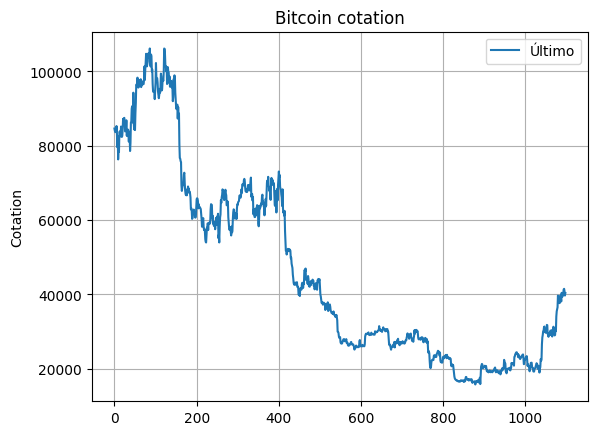

In [10]:
import matplotlib.pyplot as plt
bitcoin[['Último']].plot(grid=True)
plt.ylabel('Cotation')
plt.title('Bitcoin cotation')
plt.show()

### Retorno simples e logarítmico

In [11]:
bitcoin["simple_rtn"] = bitcoin["Último"].pct_change()
bitcoin["log_rtn"] = np.log(bitcoin["Último"]/bitcoin["Último"].shift(1))
bitcoin

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%,Média movel curta,Média movel longa,Sinal,...,RSI30,RSI200,%K10,%D10,%K30,%D30,%K200,%D200,simple_rtn,log_rtn
0,2025-04-17,84623.0,84032.2,84999.0,83822.8,"52,98K","0,70%",84623.000000,84623.000000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-16,84032.2,83648.1,85438.2,83143.5,"63,97K","0,46%",84327.600000,84327.600000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.006982,-0.007006
2,2025-04-15,83647.0,84586.8,86438.8,83602.7,"62,45K","-1,11%",84100.733333,84100.733333,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.004584,-0.004594
3,2025-04-14,84586.4,83752.8,85794.9,83705.2,"78,03K","1,02%",84222.150000,84222.150000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011231,0.011168
4,2025-04-13,83734.4,85282.5,85999.5,83049.6,"70,93K","-1,83%",84124.600000,84124.600000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.010073,-0.010124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1093,2022-04-20,41368.0,41499.0,42203.0,40915.0,"382,84M","-0,33%",39655.300000,35325.376667,1.0,...,65.955071,56.031851,69.568523,63.793893,90.278410,89.199641,93.681552,93.063528,0.021886,0.021650
1094,2022-04-19,41503.0,40809.0,41746.0,40585.0,"268,28M","1,72%",39947.500000,35698.613333,1.0,...,66.122661,56.080762,72.134575,65.138703,91.098157,88.758337,94.214338,92.693595,0.003263,0.003258
1095,2022-04-18,40803.0,39700.0,41095.0,38577.0,"484,26M","2,77%",40053.000000,36102.590000,1.0,...,64.421619,55.757528,58.829120,66.844073,86.847618,89.408062,91.451743,93.115878,-0.016866,-0.017010
1096,2022-04-17,39703.0,40382.0,40599.0,39561.0,"210,01M","-1,68%",40099.000000,36411.440000,1.0,...,61.835659,55.254556,37.920547,56.294748,80.168200,86.037992,87.110524,90.925535,-0.026959,-0.027329


#### Plotagem dos retornos

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

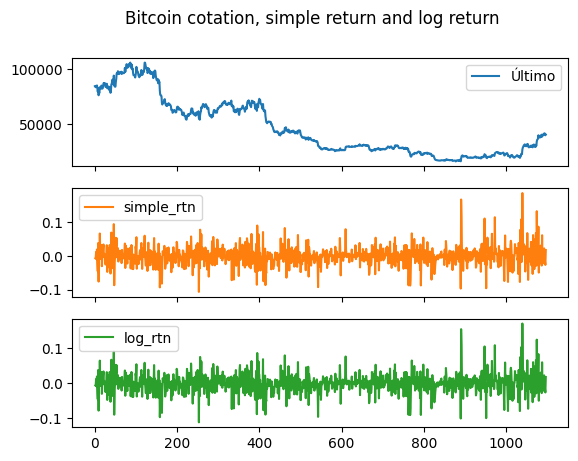

In [12]:
(
    bitcoin[["Último", "simple_rtn", "log_rtn"]]
    .plot(subplots=True, sharex=True,
    title="Bitcoin cotation, simple return and log return")
)

### Salvando o novo dataset na pasta de dados processados (```/processed```).

In [15]:
caminho = r"C:/Users/progr/OneDrive/Documentos/Miguel/PROJETOS/Rainha_de_Saba/01_data/processed/bitcoin_processed.csv"
bitcoin.to_csv(caminho, index=False)

#### Decomposição 

O link a seguir: https://chatgpt.com/share/68045c94-7e88-8006-a84a-5acc4a0a816b explica os procedimentos aplicados abaixo.

- Tendência
- Sazonal
- Residual

In [ ]:
!where pip

In [ ]:
import sys
print(sys.executable)

In [ ]:
!pip install statsmodels

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(bitcoin["Último"], model='additive', period=200)

# Cria uma figura maior
fig = decomposition.plot()
fig.set_size_inches(9, 8)  # largura x altura em polegadas

# Define o título com fonte menor
fig.suptitle("Decomposição", fontsize=14)

# Diminui o tamanho das fontes nos eixos
for ax in fig.axes:
    ax.tick_params(labelsize=8)
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)
